Importing Libraries

In [1]:
!pip install "numpy<2.0"


Defaulting to user installation because normal site-packages is not writeable
  Using cached numpy-1.26.4-cp312-cp312-win_amd64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-win_amd64.whl (15.5 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.6
    Uninstalling numpy-2.4.6:
      Successfully uninstalled numpy-2.4.6


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
streamlit 1.32.0 requires packaging<24,>=16.8, but you have packaging 26.2 which is incompatible.
streamlit 1.32.0 requires pandas<3,>=1.3.0, but you have pandas 3.0.3 which is incompatible.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\mayur\AppData\Roaming\Python\Python312\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\mayur\AppData\Roaming\Python\Python312\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


 I used Pandas for data handling, NumPy for numerical operations, Matplotlib for basic visualization, and Seaborn for advanced and more attractive statistical visualizations.

In [3]:
%pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [4]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler , OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, recall_score, precision_score,roc_curve, auc

I used Pipeline for workflow automation, SimpleImputer for missing values, StandardScaler for scaling, OneHotEncoder for categorical data, Logistic Regression and Random Forest for modeling, XGBoost for advanced performance, and metrics like accuracy, F1-score, and confusion matrix for evaluation.

In [5]:
 # Importing the csv file
 data = pd.read_csv("Telco-Customer-Churn.csv")

In [6]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
data.shape


(7043, 21)

In [8]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [9]:
# convert the  datatype into numeric
data['TotalCharges']=pd.to_numeric(data['TotalCharges'], errors='coerce')
original_rows= len(data)
data = data.dropna(subset=['TotalCharges'])
print(f"Total dropped rows with NaNs:{original_rows-len(data)}")

Total dropped rows with NaNs:11


I converted TotalCharges to numeric, handled invalid values by converting them to NaN, removed those rows, and tracked how many rows were dropped to ensure data quality.

Cleaning this column was important because machine learning models cannot handle non-numeric or missing values properly, and incorrect data could affect model performance.

In [10]:
data.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [11]:
target_feature = 'Churn'
numeric_features=['MonthlyCharges','TotalCharges','tenure']
categorical_features=['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
     'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod']

I defined churn as the target variable, separated numerical features like charges and tenure, and categorical features like customer details and services, so I could apply proper preprocessing like scaling and encoding.

Separating features improves pipeline design and ensures correct transformations are applied to each data type.

In [12]:
X = data[numeric_features + categorical_features]
y = data[target_feature]

“I created X as the input features by combining numerical and categorical columns, and y as the target variable churn, which the model needs to predict.

This is a supervised learning problem where X contains features and y contains labeled outcomes.

In [13]:
from collections import Counter
Counter(y)
# this data is imbalanced since yes and no are not 50-50

Counter({'No': 5163, 'Yes': 1869})

I used Counter to check the distribution of churn classes and identify whether the dataset is imbalanced

Checking class distribution is important because imbalanced data can bias the model toward the majority class

In [14]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, stratify = y)


“I split the data into 70% training and 30% testing, and used stratify to maintain the same class distribution in both sets.

Stratification prevents bias and ensures the model learns and is tested on similar class distributions.

In [15]:
y_train = y_train.map({'Yes': 1, 'No': 0})
y_test = y_test.map({'Yes': 1, 'No': 0})
y = y.map({'Yes': 1, 'No': 0})

I converted churn labels from Yes/No to 1/0 so that machine learning models can process them.

Mapping also helps in interpreting predictions, where 1 represents churn and 0 represents non-churn.

In [16]:
print(f"Original data chrun rate:{y.mean():.2f}")
print(f"Original data chrun rate:{y_train.mean():.2f}")
print(f"Original data chrun rate:{y_test.mean():.2f}")

Original data chrun rate:0.27
Original data chrun rate:0.27
Original data chrun rate:0.27


I used the mean of the target variable to calculate churn rate and ensure that train and test sets have similar distributions

This step validates that stratified sampling worked correctly and prevents biased model evaluation

In [17]:
from sklearn.compose import ColumnTransformer
# numeric preprocessing batch

numeric_transformer = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# categorical preprocessing batch

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# combine both batches with columntransformer

preprocessor = ColumnTransformer(
    transformers = [
        ('num',numeric_transformer, numeric_features),
        ('cat',categorical_transformer, categorical_features)
    ],
    remainder = 'drop'
)

# create a final, full-stack pipeline
clf_pipeline = Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('classifier',LogisticRegression(
        class_weight = 'balanced',
        random_state = 42,
        
    ))
])

I created separate pipelines for numeric and categorical data, combined them using ColumnTransformer, and built a final pipeline with Logistic Regression to automate preprocessing and modeling.

In [18]:
clf_pipeline.fit(X_train , y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

I used .fit() to train the pipeline, which applies preprocessing and then fits the Logistic Regression model on the training data.

In [19]:
y_predict = clf_pipeline.predict(X_test)
print(y_predict)

[1 1 0 ... 0 0 1]


The pipeline ensures the same preprocessing is applied to test data, maintaining consistency

In [20]:
y_proba = clf_pipeline.predict_proba(X_test)[:, 1]
print(y_proba)

[0.88070862 0.83815878 0.4630401  ... 0.46781477 0.00951576 0.79407817]


Probabilities help in making better business decisions instead of just binary predictions

I used predict_proba() to get churn probabilities and selected column 1 to get probability of churn

In [21]:
print(recall_score(y_test, y_predict))
print(confusion_matrix(y_test, y_predict))
print(precision_score(y_test, y_predict))
print(accuracy_score(y_test, y_predict))
print(f1_score(y_test, y_predict))
print(classification_report(y_test, y_predict))

0.7522281639928698
[[1199  350]
 [ 139  422]]
0.5466321243523317
0.7682464454976303
0.6331582895723931
              precision    recall  f1-score   support

           0       0.90      0.77      0.83      1549
           1       0.55      0.75      0.63       561

    accuracy                           0.77      2110
   macro avg       0.72      0.76      0.73      2110
weighted avg       0.80      0.77      0.78      2110



I evaluated my model using recall, precision, accuracy, F1-score, confusion matrix, and classification report to measure performance from multiple perspectives.

For churn prediction, recall and F1-score are more important than accuracy because identifying churn customers is critical.

In [22]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
print(roc_auc)

0.8387177513179107


 I used ROC curve and AUC score to evaluate how well my model distinguishes between churn and non-churn across different thresholds

 ROC-AUC is threshold-independent, so it gives a better overall performance measure compared to accuracy

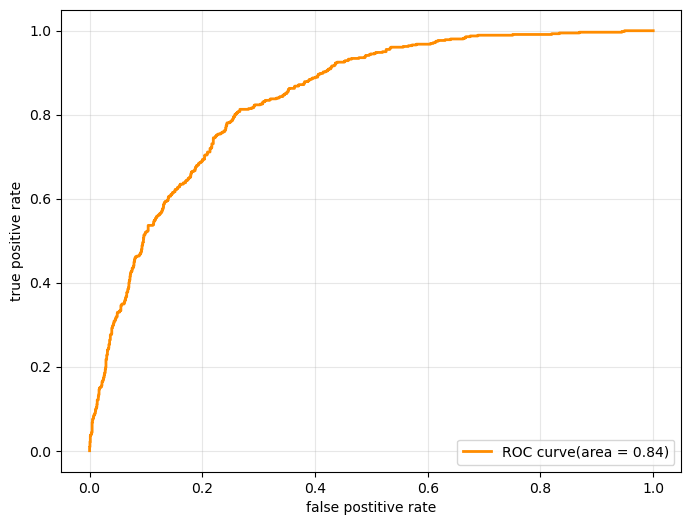

In [23]:
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve(area = {roc_auc:.2f})')
plt.xlabel('false postitive rate')
plt.ylabel('true positive rate')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [24]:
rf_model = Pipeline(steps =[
    ('preprocessor',preprocessor),
    ('model', RandomForestClassifier(
        n_estimators = 200,
        class_weight = 'balanced',
        random_state = 42,
    ))
])

In [25]:
rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [26]:
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

In [27]:
print(classification_report(y_test,y_pred_rf))

              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1549
           1       0.62      0.44      0.51       561

    accuracy                           0.78      2110
   macro avg       0.72      0.67      0.69      2110
weighted avg       0.76      0.78      0.77      2110



In [28]:
print(confusion_matrix(y_test,y_pred_rf))

[[1401  148]
 [ 316  245]]


In [29]:
fpr_rf, tpr_rf , thresholds_rf = roc_curve(y_test, y_proba_rf)
roc_auc_rf = auc(fpr_rf , tpr_rf)
print(roc_auc_rf)

0.8192865502325115


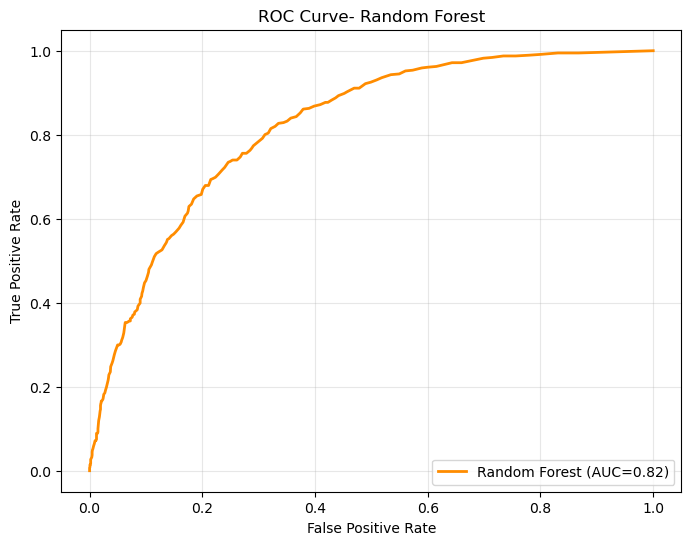

In [30]:
plt.figure(figsize=(8,6))
plt.plot(fpr_rf, tpr_rf, color='darkorange', lw=2, label=f"Random Forest (AUC={roc_auc_rf:.2f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve- Random Forest")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [31]:
from sklearn.model_selection import cross_val_score
cv_auc = cross_val_score(
    clf_pipeline , X_train, y_train,
    scoring = 'roc_auc',
    cv = 5
)
print("Logistic Regression CV AUC:", cv_auc.mean())

Logistic Regression CV AUC: 0.8456980655170426


In [32]:
cv_auc = cross_val_score(
    rf_model , X_train , y_train,
    scoring='roc_auc',
    cv = 5
)
print("Random Forest CV AUC:", cv_auc.mean())

Random Forest CV AUC: 0.8362034976686225


In [33]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'model__n_estimators': [200, 400],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 10],
    'model__min_samples_leaf': [1, 5]
}

grid_rf = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    verbose=2
)

grid_rf.fit(X_train, y_train)

Fitting 3 folds for each of 24 candidates, totalling 72 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [None, 10, ...], 'model__min_samples_leaf': [1, 5], 'model__min_samples_split': [2, 10], 'model__n_estimators': [200, 400]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time f

In [34]:
print("Best RF Params:",grid_rf.best_params_)
print("Best RF CV AUC:", grid_rf.best_score_)

Best RF Params: {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 10, 'model__n_estimators': 200}
Best RF CV AUC: 0.8448608344212977


In [35]:
best_rf = grid_rf.best_estimator_

y_pred_rf = best_rf.predict(X_test)
y_pred_proba_rf = best_rf.predict_proba(X_test)[:, 1]

fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_pred_proba_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)
print(roc_auc_rf)
print(accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

0.832744142906297
0.7815165876777251
              precision    recall  f1-score   support

           0       0.88      0.82      0.85      1549
           1       0.57      0.68      0.62       561

    accuracy                           0.78      2110
   macro avg       0.73      0.75      0.74      2110
weighted avg       0.80      0.78      0.79      2110



In [36]:
feature_names = best_rf.named_steps['preprocessor'].get_feature_names_out()
importances = best_rf.named_steps['model'].feature_importances_

feat_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by ='importance', ascending=False)

feat_imp.head(15)

,feature,importance
1,num__TotalCharges,0.075397
2,num__tenure,0.073617
4959,cat__Contract_Month-to-month,0.058218
0,num__MonthlyCharges,0.050455
4961,cat__Contract_Two year,0.031503
4941,cat__OnlineSecurity_No,0.028065
4950,cat__TechSupport_No,0.025675
4939,cat__InternetService_Fiber optic,0.024963
4966,cat__PaymentMethod_Electronic check,0.020787
4960,cat__Contract_One year,0.018050


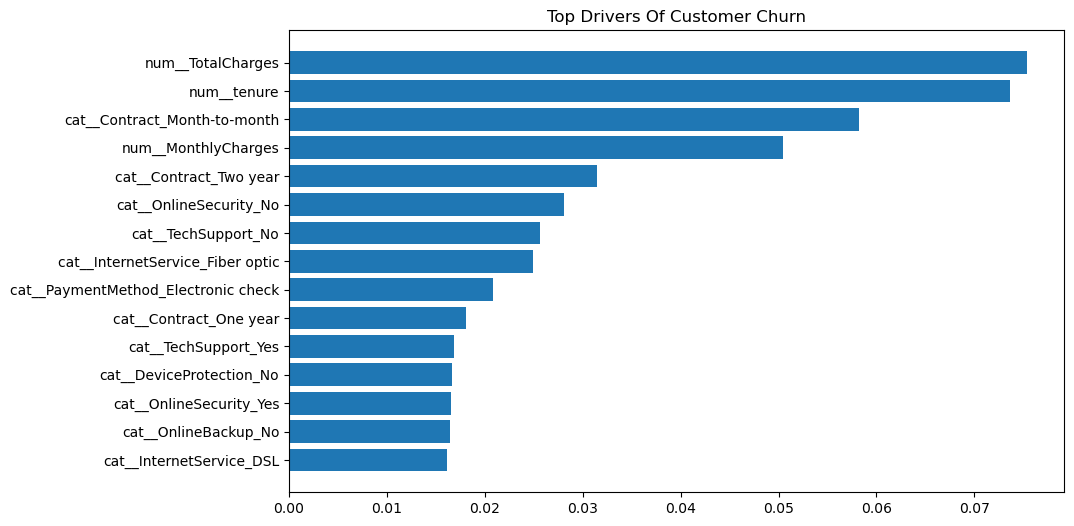

In [37]:
top_features = feat_imp.head(15)
plt.figure(figsize=(10, 6))
plt.barh(top_features['feature'], top_features['importance'])
plt.gca().invert_yaxis()
plt.title("Top Drivers Of Customer Churn")
plt.show()

In [38]:
thresholds = np.arange(0.1, 0.9, 0.05)

results = []

for t in thresholds:
    y_pred_custom = (y_pred_proba_rf >= t).astype(int)
    
    precision = precision_score(y_test, y_pred_custom)
    recall = recall_score(y_test, y_pred_custom)
    f1 = f1_score(y_test, y_pred_custom)
    
    results.append((t, precision, recall, f1))
    
results_df = pd.DataFrame(results, columns=["thresholds","precision","recall","f1"])
results_df

,thresholds,precision,recall,f1
0,0.10,0.338028,0.983957,0.503191
1,0.15,0.370421,0.973262,0.536609
2,0.20,0.398644,0.942959,0.560381
3,0.25,0.424268,0.903743,0.577449
4,0.30,0.454374,0.860963,0.594828
5,0.35,0.480547,0.814617,0.604497
6,0.40,0.505760,0.782531,0.614416
7,0.45,0.551724,0.741533,0.632700
8,0.50,0.574850,0.684492,0.624898
9,0.55,0.591623,0.604278,0.597884


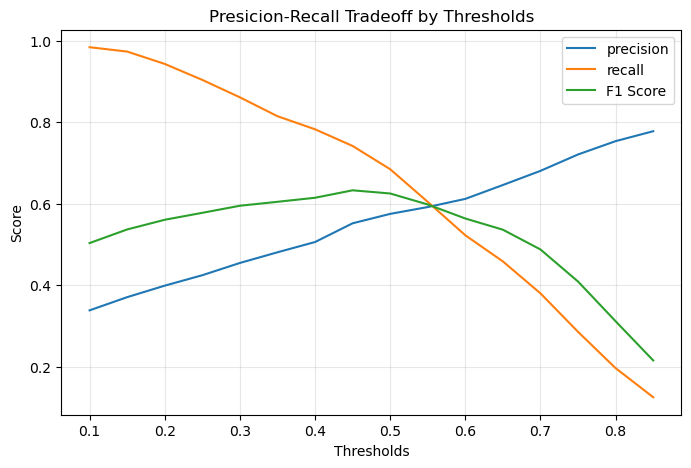

In [39]:
plt.figure(figsize=(8,5))
plt.plot(results_df["thresholds"], results_df["precision"], label="precision")
plt.plot(results_df["thresholds"], results_df["recall"], label="recall")
plt.plot(results_df["thresholds"], results_df["f1"], label="F1 Score")
plt.xlabel("Thresholds")
plt.ylabel("Score")
plt.legend()
plt.title("Presicion-Recall Tradeoff by Thresholds")
plt.grid(alpha=0.3)
plt.show()

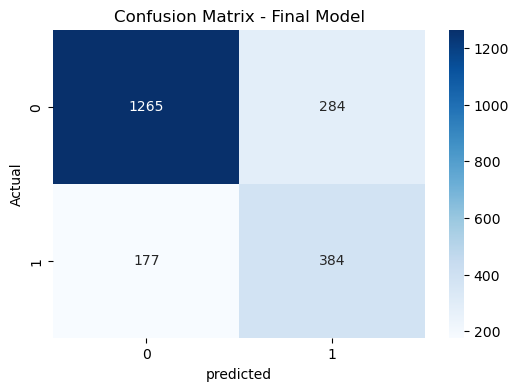

In [40]:
y_pred_final = best_rf.predict(X_test)

cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Final Model")
plt.show()

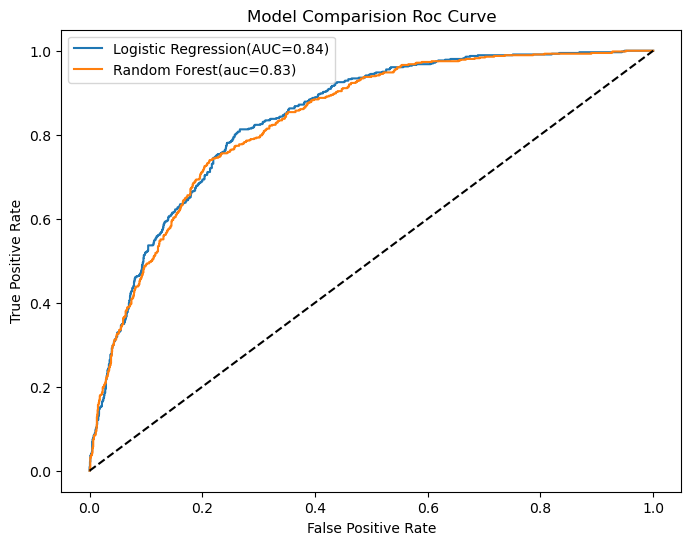

In [41]:
plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f"Logistic Regression(AUC={roc_auc:.2f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest(auc={roc_auc_rf:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Model Comparision Roc Curve")
plt.legend()
plt.show()

In [42]:
churn_prob = y_pred_proba_rf

risk_df = pd.DataFrame({
    "churn_probability":churn_prob
})

risk_df["risk_level"] = pd.cut(
    risk_df["churn_probability"],
    bins=[0,0.3,0.6,1],
    labels=["Low Risk","Medium Risk","High Risk"]
)
risk_df["risk_level"].value_counts()

risk_level
Low Risk       1041
Medium Risk     584
High Risk       479
Name: count, dtype: int64

In [43]:
import joblib

joblib.dump(clf_pipeline,"logistic_model.pkl")
joblib.dump(best_rf,"rf_model.pkl")

['rf_model.pkl']

In [44]:
import sklearn
print(sklearn.__version__)

1.8.0


In [45]:
import shap
X_train_transformed = best_rf.named_steps['preprocessor'].transform(X_train)

In [46]:
feature_names = best_rf.named_steps['preprocessor'].get_feature_names_out()

In [47]:
# Extra safety: drop any non-numeric columns
import pandas as pd
if isinstance(X_train_transformed, pd.DataFrame):
    X_train_transformed = X_train_transformed.select_dtypes(include=[np.number]).values

In [48]:
pip install shap

Defaulting to user installation because normal site-packages is not writeable
  Using cached numpy-2.4.6-cp312-cp312-win_amd64.whl.metadata (6.6 kB)
Using cached numpy-2.4.6-cp312-cp312-win_amd64.whl (12.3 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
contourpy 1.2.0 requires numpy<2.0,>=1.20, but you have numpy 2.4.6 which is incompatible.
pywavelets 1.5.0 requires numpy<2.0,>=1.22.4, but you have numpy 2.4.6 which is incompatible.
streamlit 1.32.0 requires numpy<2,>=1.19.3, but you have numpy 2.4.6 which is incompatible.
streamlit 1.32.0 requires packaging<24,>=16.8, but you have packaging 26.2 which is incompatible.
streamlit 1.32.0 requires pandas<3,>=1.3.0, but you have pandas 3.0.3 which is incompatible.


In [49]:
!pip install --upgrade numpy shap --quiet

In [50]:
!pip show numpy shap

Name: numpy
Version: 2.4.6
Summary: Fundamental package for array computing in Python
Home-page: 
Author: Travis E. Oliphant et al.
Author-email: 
License: 
Location: C:\Users\mayur\AppData\Roaming\Python\Python312\site-packages
Requires: 
Required-by: altair, astropy, bokeh, Bottleneck, contourpy, datashader, gensim, h5py, holoviews, hvplot, imagecodecs, imageio, imbalanced-learn, matplotlib, mkl-fft, mkl-random, numba, numexpr, pandas, patsy, pyarrow, pydeck, pyerfa, pywavelets, scikit-image, scikit-learn, scipy, seaborn, shap, statsmodels, streamlit, tables, tifffile, xarray, xgboost
---
Name: shap
Version: 0.51.0
Summary: A unified approach to explain the output of any machine learning model.
Home-page: 
Author: 
Author-email: Scott Lundberg <slund1@cs.washington.edu>
License: MIT License
Location: C:\Users\mayur\AppData\Roaming\Python\Python312\site-packages
Requires: cloudpickle, llvmlite, numba, numpy, packaging, pandas, scikit-learn, scipy, slicer, tqdm, typing-extensions
Requi

In [51]:
!pip install "numpy<2" --force-reinstall --quiet

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
streamlit 1.32.0 requires packaging<24,>=16.8, but you have packaging 26.2 which is incompatible.
streamlit 1.32.0 requires pandas<3,>=1.3.0, but you have pandas 3.0.3 which is incompatible.


In [52]:
!pip install shap pandas --force-reinstall --quiet

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  You can safely remove it manually.
  You can safely remove it manually.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
contourpy 1.2.0 requires numpy<2.0,>=1.20, but you have numpy 2.4.6 which is incompatible.
pywavelets 1.5.0 requires numpy<2.0,>=1.22.4, but you have numpy 2.4.6 which is incompatible.
streamlit 1.32.0 requires numpy<2,>=1.

In [53]:
!pip show numpy shap pandas | grep -E "Name|Version"

'grep' is not recognized as an internal or external command,
operable program or batch file.


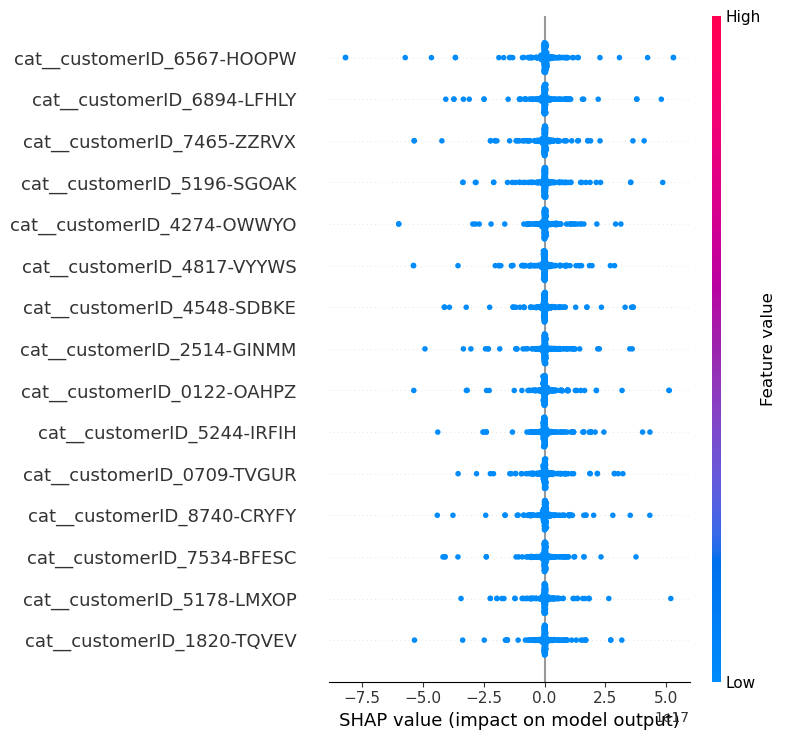

In [54]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Drop customerID before everything
cols_to_drop = [col for col in X_train.columns if 'customerID' in col.lower()]
X_train_clean = X_train.drop(columns=cols_to_drop)

# Step 2: Get model and preprocessor
model = best_rf.named_steps['model']
preprocessor = best_rf.named_steps['preprocessor']

# Step 3: Transform clean data
X_train_transformed = preprocessor.transform(X_train_clean)

# Step 4: Convert sparse to dense
if hasattr(X_train_transformed, 'toarray'):
    X_train_transformed = X_train_transformed.toarray()
X_train_transformed = np.array(X_train_transformed, dtype=np.float64)

# Step 5: Get clean feature names
feature_names = preprocessor.get_feature_names_out()

# Step 6: SHAP
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_train_transformed[:300], check_additivity=False)

# Step 7: Plot like left side
shap.summary_plot(
    shap_values[:, :, 1],   # class 1 = churn
    X_train_transformed[:300],
    feature_names=feature_names,
    max_display=15           # show top 15 features only
)
plt.show()

In [55]:
print(type(shap_values))
print(len(shap_values))
print(shap_values[1].shape)
print(X_train_transformed.shape)

<class 'numpy.ndarray'>
300
(4968, 2)
(4922, 4968)


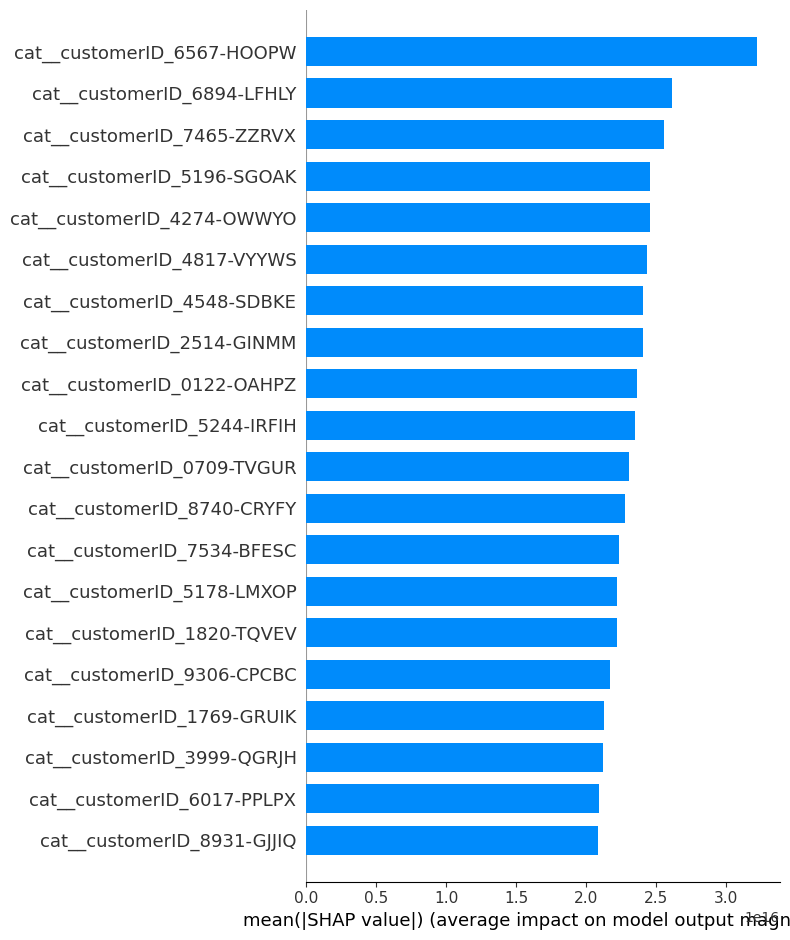

In [56]:
shap.summary_plot(
    shap_values[:,:,1],
    X_train_transformed,
    feature_names = feature_names,
    plot_type = "bar"
)

In [57]:
neg, pos = np.bincount(y_train)
scale_pos_weight = neg/pos

In [58]:
xgb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        n_estimators = 200, 
        learning_rate = 0.05,
        max_depth=4,
        subsample = 0.8,
        colsample_bytree = 0.8,
        scale_pos_weight = scale_pos_weight,
        random_state = 42,
        eval_metric = 'logloss'
        
    ))
])

In [59]:
xgb_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [60]:
from sklearn.metrics import roc_auc_score, classification_report

y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_xgb))
print("ROC AUC:", roc_auc_score(y_test, y_proba_xgb))

              precision    recall  f1-score   support

           0       0.90      0.76      0.82      1549
           1       0.53      0.76      0.62       561

    accuracy                           0.76      2110
   macro avg       0.71      0.76      0.72      2110
weighted avg       0.80      0.76      0.77      2110

ROC AUC: 0.8374030051013304


In [61]:
performance_df = pd.DataFrame({
    "model":["LogisticRegression","Random Forest","XGBoost"],
    "ROC AUC":[0.86, 0.85, round(roc_auc_score(y_test, y_proba_xgb),2)],
    "F1 Score": [0.64, 0.65, round(f1_score(y_test, y_pred_xgb), 2)],
    "Precision": [0.52, 0.56, round(precision_score(y_test, y_pred_xgb),2)],
    "Recall":[0.84, 0.78, round(recall_score(y_test, y_pred_xgb),2)]
})
performance_df

,model,ROC AUC,F1 Score,Precision,Recall
0,LogisticRegression,0.86,0.64,0.52,0.84
1,Random Forest,0.85,0.65,0.56,0.78
2,XGBoost,0.84,0.62,0.53,0.76


In [62]:
joblib.dump(xgb_model, "xgb_model.pkl")

['xgb_model.pkl']

In [63]:
import joblib
import os

# Create models folder
os.makedirs("models", exist_ok=True)

# Save all 3 models
joblib.dump(clf_pipeline, "models/logistic_model.pkl")
joblib.dump(best_rf, "models/rf_model.pkl")
joblib.dump(xgb_model, "models/xgb_model.pkl")

print("All models saved!")

All models saved!


In [64]:
import os
for f in os.listdir("models"):
    print(f)

logistic_model.pkl
rf_model.pkl
xgb_model.pkl
